In [1]:
import pandas as pd
import numpy as np
import joblib
from datetime import datetime, timedelta
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import joblib

2024-12-21 13:36:01.626524: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-12-21 13:36:08.413546: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1734762968.547408    1940 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1734762968.583636    1940 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-12-21 13:36:08.944623: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [2]:
def preprocess_data(file_path):
    df = pd.read_csv(file_path, delimiter=';', decimal=',')
    df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'].str.replace('.', ':'), dayfirst=True)

    df = df.drop(['Date', 'Time'], axis=1)
    df = df.replace(-200, np.nan)
    df = df.fillna(method='ffill')

    # Remove unexpected columns
    unexpected_columns = [col for col in df.columns if col.startswith('Unnamed')]
    df = df.drop(unexpected_columns, axis=1, errors='ignore')
    
    return df

In [3]:
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:(i + sequence_length)])
        y.append(data[i + sequence_length, 0])
    return np.array(X), np.array(y)

In [4]:
def build_model(input_shape):
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    
    model.compile(optimizer=Adam(learning_rate=0.001),
                 loss='mse',
                 metrics=['mae'])
    return model

In [5]:
def evaluate_air_quality(co_level):
    if co_level < 4.4:
        return "Good"
    elif co_level < 9.4:
        return "Moderate"
    elif co_level < 12.4:
        return "Unhealthy for Sensitive Groups"
    elif co_level < 15.4:
        return "Unhealthy"
    else:
        return "Very Unhealthy"

In [6]:
def train_air_quality_model(file_path, sequence_length=24):
    df = preprocess_data(file_path)
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(df.select_dtypes(include=[np.number]))
    
    X, y = create_sequences(scaled_data, sequence_length)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    model = build_model((sequence_length, X.shape[2]))
    history = model.fit(X_train, y_train,
                       epochs=50,
                       batch_size=32,
                       validation_split=0.2,
                       verbose=1)
    
    joblib.dump(scaler, 'scaler.pkl')
                       
    return model, scaler, history


In [7]:
def predict_air_quality(model, scaler, current_conditions, sequence_length=1):
    # Ensure the same preprocessing steps are applied
    print("Original current_conditions:")
    print(current_conditions.head())  # Debugging step: View the top rows of the DataFrame
    
    # Select only numerical columns
    current_conditions = current_conditions.select_dtypes(include=[np.number])
    print("\nFiltered numerical columns:")
    print(current_conditions.head())  # Debugging step: Check numerical columns

    # Reorder columns to match scaler's expected order
    if hasattr(scaler, "feature_names_in_"):
        expected_features = scaler.feature_names_in_
        print("\nExpected features by scaler:", expected_features)  # Scaler's expected features
        print("Current features in DataFrame:", current_conditions.columns.tolist())
        
        # Reorder DataFrame columns
        try:
            current_conditions = current_conditions[expected_features]
        except KeyError as e:
            print("Error: Missing features in current_conditions:")
            print(e)
            raise

    # Scale the input data
    try:
        scaled_input = scaler.transform(current_conditions)
    except ValueError as e:
        print("\nError during scaling:", e)
        print("Current_conditions shape:", current_conditions.shape)
        raise  # Re-raise the error for further inspection

    # Ensure the sequence length matches
    if len(scaled_input) < sequence_length:
        raise ValueError(
            f"Insufficient data: Only {len(scaled_input)} rows available, but sequence_length is {sequence_length}"
        )

    sequence = scaled_input[-sequence_length:].reshape(1, sequence_length, -1)
    print("\nInput sequence shape for model prediction:", sequence.shape)

    # Predict the CO level
    predicted_co = model.predict(sequence)[0][0]

    # Reverse scaling for interpretation
    predicted_co = scaler.inverse_transform([[predicted_co] + [0] * (scaled_input.shape[1] - 1)])[0][0]
    quality_status = evaluate_air_quality(predicted_co)

    return predicted_co, quality_status


In [8]:
def save_model_artifacts(model, scaler, filepath_prefix='air_quality'):
    model.save(f'{filepath_prefix}_model.h5')
    joblib.dump(scaler, f'{filepath_prefix}_scaler.joblib')

In [9]:
def load_model_artifacts(filepath_prefix='air_quality'):
    model = load_model(f'{filepath_prefix}_model.h5')
    scaler = joblib.load(f'{filepath_prefix}_scaler.joblib')
    return model, scaler

In [10]:
def generate_single_test_data():
    # Fixed date and time for the single sample
    date = datetime(2023, 1, 1, 0, 0)
    
    # Generate random data for each column
    data = {
        'Date': date.strftime('%d/%m/%Y'),
        'Time': date.strftime('%H.%M.%S'),
        'C6H6(GT)': np.random.uniform(0, 20),  # Benzene's expected format
        'CO(GT)': np.random.uniform(0, 10),
        'NMHC(GT)': np.random.uniform(0, 100),
        'NO2(GT)': np.random.uniform(0, 150),
        'NOx(GT)': np.random.uniform(0, 200),
        'PT08.S1(CO)': np.random.uniform(800, 1200),
        'PT08.S2(NMHC)': np.random.uniform(700, 1100),
        'PT08.S3(NOx)': np.random.uniform(800, 1200),
        'PT08.S4(NO2)': np.random.uniform(900, 1300),
        'PT08.S5(O3)': np.random.uniform(800, 1200),
        'T': np.random.uniform(10, 30),
        'RH': np.random.uniform(20, 80),
        'AH': np.random.uniform(0.5, 2.0)
    }
    
    return pd.DataFrame([data])

/tmp/ipykernel_1940/1064574668.py:7: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')
I0000 00:00:1734762981.480330    1940 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3586 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6
/home/jasonc/AQM_AI/AQM/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50


I0000 00:00:1734762985.003132    2443 cuda_dnn.cc:529] Loaded cuDNN version 90300


189/189 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 0.0256 - mae: 0.1125 - val_loss: 0.0106 - val_mae: 0.0848
Epoch 2/50
189/189 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0094 - mae: 0.0726 - val_loss: 0.0066 - val_mae: 0.0577
Epoch 3/50
189/189 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0077 - mae: 0.0629 - val_loss: 0.0048 - val_mae: 0.0507
Epoch 4/50
189/189 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0053 - mae: 0.0525 - val_loss: 0.0036 - val_mae: 0.0409
Epoch 5/50
189/189 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0049 - mae: 0.0491 - val_loss: 0.0031 - val_mae: 0.0384
Epoch 6/50
189/189 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0043 - mae: 0.0462 - val_loss: 0.0032 - val_mae: 0.0413
Epoch 7/50
189/189 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0043 - mae: 0.0461 - val_loss: 0.0030 - val_mae: 0.0372
Epoch 8/50
189/189 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0038 - mae: 0.0435 - val_loss: 0.0028 - val_mae: 0.0365
Epoch 9/50
189/189 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss

Original current_conditions:
         Date      Time  C6H6(GT)    CO(GT)  NMHC(GT)   NO2(GT)     NOx(GT)  \
0  01/01/2023  00.00.00  6.499901  4.966697  7.609761  2.245155  150.028522   

   PT08.S1(CO)  PT08.S2(NMHC)  PT08.S3(NOx)  PT08.S4(NO2)  PT08.S5(O3)  \
0  1086.292877     904.957471     890.66811    938.609225   929.321607   

           T         RH        AH  
0  10.697933  29.515083  1.600745  

Filtered numerical columns:
   C6H6(GT)    CO(GT)  NMHC(GT)   NO2(GT)     NOx(GT)  PT08.S1(CO)  \
0  6.499901  4.966697  7.609761  2.245155  150.028522  1086.292877   

   PT08.S2(NMHC)  PT08.S3(NOx)  PT08.S4(NO2)  PT08.S5(O3)          T  \
0     904.957471     890.66811    938.609225   929.321607  10.697933   

          RH        AH  
0  29.515083  1.600745  

Expected features by scaler: ['CO(GT)' 'PT08.S1(CO)' 'NMHC(GT)' 'C6H6(GT)' 'PT08.S2(NMHC)' 'NOx(GT)'
 'PT08.S3(NOx)' 'NO2(GT)' 'PT08.S4(NO2)' 'PT08.S5(O3)' 'T' 'RH']
Current features in DataFrame: ['C6H6(GT)', 'CO(GT)', 'NMHC

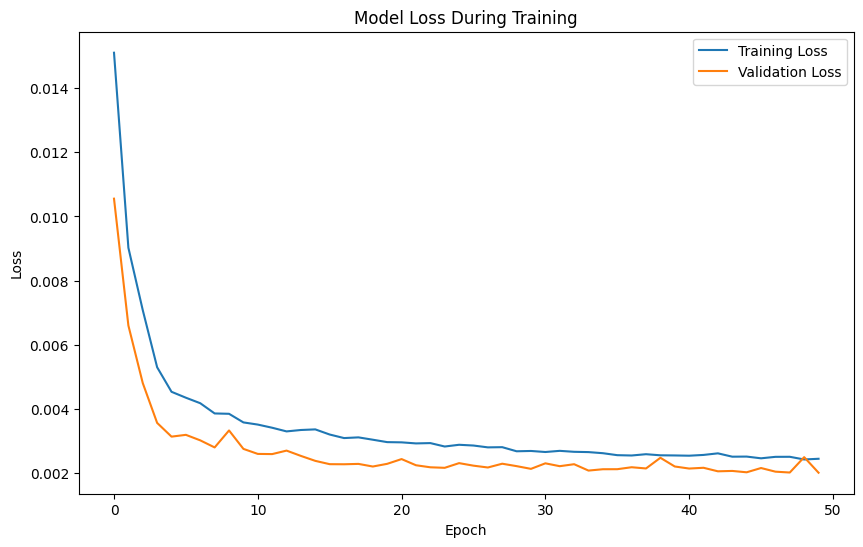

In [11]:
if __name__ == "__main__":
    # Generate and save test data
    test_df = generate_single_test_data()
    test_df.to_csv('test_air_quality.csv', sep=';', decimal=',', index=False)
    
    # Train model
    model, scaler, history = train_air_quality_model('AirQuality.csv')
    
    # Save model
    save_model_artifacts(model, scaler)
    
    # Make predictions
    co_level, quality = predict_air_quality(model, scaler, test_df)
    
    #show current air data
    print("Current air data:")
    # print(current_conditions)
    print(f"Predicted CO Level: {co_level:.2f} mg/m³")
    print(f"Air Quality Status: {quality}")
    
    # Plot training history
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss During Training')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()